***Objectives***
1. Preprocess the data (handle categorical variables, feature scaling)
2. Train and test multiple classification models (Decision Tree, Logistic Regression, Random Forest)
3. Evaluate models using accuracy, precision, recall, and F1-score
4. Perform hyperparameter tuning using Grid Search

**Dataset:** Telecom Customer Churn Dataset  
**Tools:** Python, scikit-learn, pandas, matplotlib, seaborn

***Step 1: Import Libraries***

We begin by importing all the necessary libraries for data processing, model building, and visualization.

In [11]:
# Mount Drive & Import Libraries
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print('All libraries imported successfully!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All libraries imported successfully!


***Step 2: Load the Dataset***

The churn dataset is split into two files (80% training, 20% testing). We load both and combine them for preprocessing, then split properly for model training.

In [12]:
# Load both train and test splits
df_train = pd.read_csv('/content/drive/MyDrive/Datasets/Codveda Technology/churn-bigml-80.csv')
df_test  = pd.read_csv('/content/drive/MyDrive/Datasets/Codveda Technology/churn-bigml-20.csv')

# Combine for unified preprocessing
df = pd.concat([df_train, df_test], ignore_index=True)

print('Combined Dataset Shape:', df.shape)
df.head()

Combined Dataset Shape: (3333, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [13]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

In [14]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


***Step 3: Exploratory Data Analysis (EDA)***

Before building models, let's understand the data: check class balance, explore feature distributions, and look at churn rates.

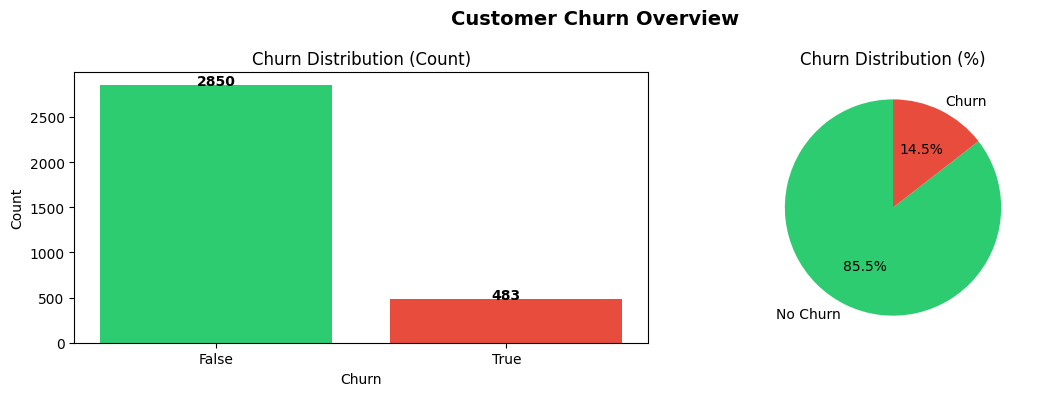

Churn distribution plot saved.


In [15]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index.astype(str), churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution (Count)')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn Distribution (%)')

plt.suptitle('Customer Churn Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Codveda Technology/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Churn distribution plot saved.')

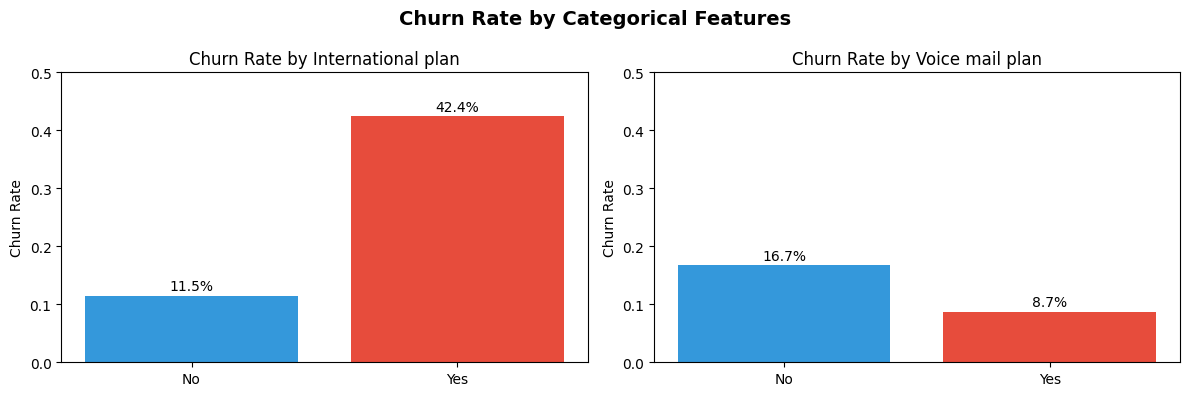

In [16]:
# Churn rate by International Plan and Voice Mail Plan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['International plan', 'Voice mail plan']):
    ct = df.groupby(col)['Churn'].mean().reset_index()
    ax.bar(ct[col], ct['Churn'], color=['#3498db', '#e74c3c'])
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.set_ylim(0, 0.5)
    for i, row in ct.iterrows():
        ax.text(i, row['Churn'] + 0.01, f"{row['Churn']:.1%}", ha='center')

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Codveda Technology/churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

***Step 4: Data Preprocessing***

We need to:
- Encode categorical columns (Yes/No → 1/0, True/False → 1/0)
- Drop non-informative columns like `State` and `Area code`
- Scale numerical features using `StandardScaler`

In [17]:
df_processed = df.copy()

# Drop low-value identifier columns
df_processed.drop(columns=['State', 'Area code'], inplace=True)

# Encode Yes/No columns
binary_cols = ['International plan', 'Voice mail plan']
for col in binary_cols:
    df_processed[col] = df_processed[col].map({'Yes': 1, 'No': 0})

# Encode target column (True/False -> 1/0)
df_processed['Churn'] = df_processed['Churn'].astype(int)

print('Processed DataFrame shape:', df_processed.shape)
print('\nData types after encoding:')
print(df_processed.dtypes)
df_processed.head()

Processed DataFrame shape: (3333, 18)

Data types after encoding:
Account length              int64
International plan          int64
Voice mail plan             int64
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                       int64
dtype: object


,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


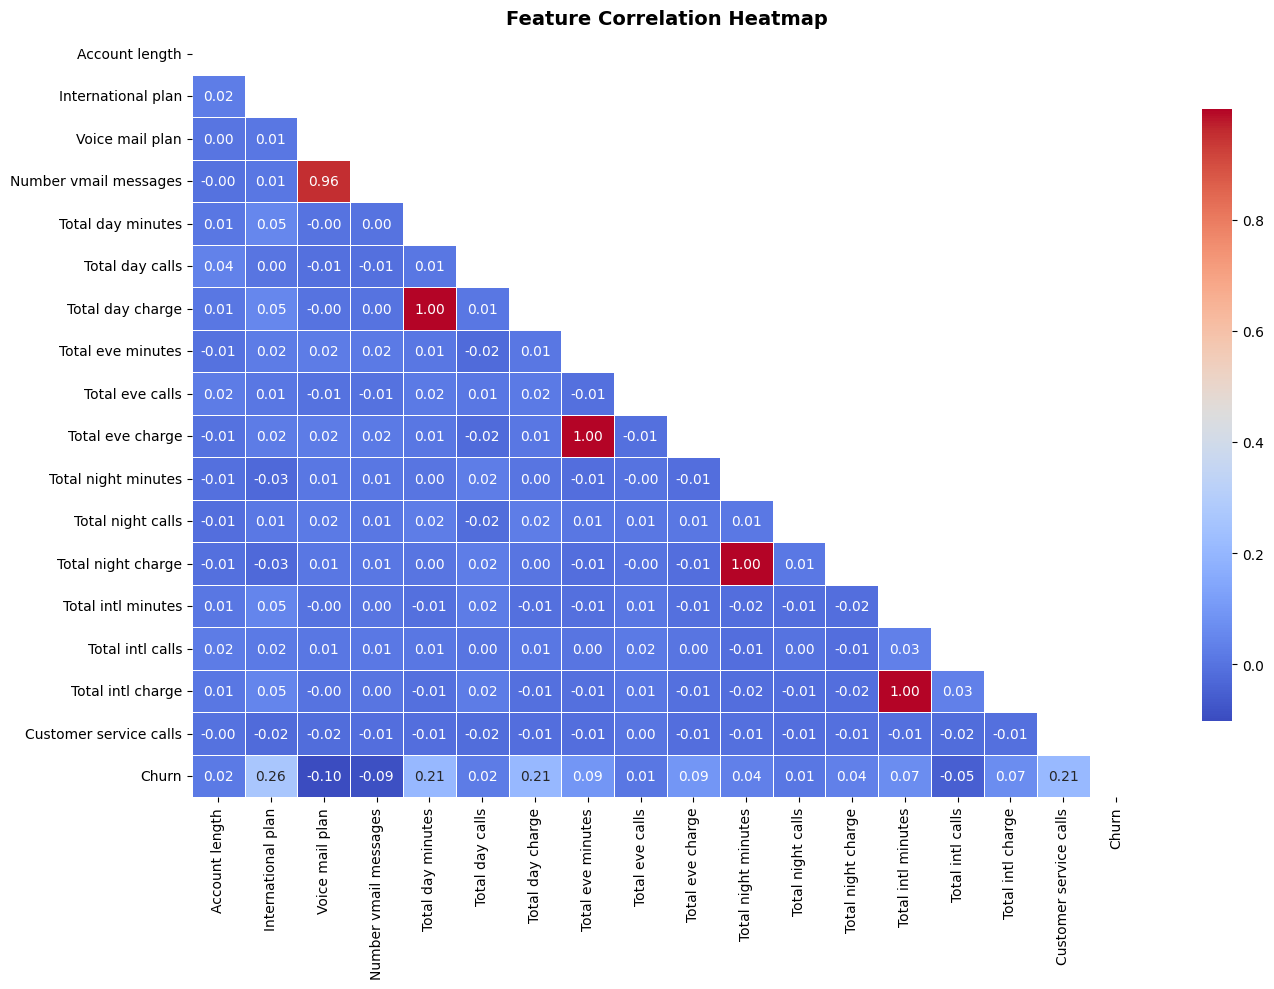

Heatmap saved.


In [18]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df_processed.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/Codveda Technology/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved.')